# Microwave-optical entanglement

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from copy import copy

from src import Transducer, covariance, log_negativity

from src.plots import *
from src.params import *

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

### Numerics

In [2]:
# Temporal mode width [ns / 2π].
tau = 100.0

# Beam-splitter interaction relative strength z = g_t/g_s.
z_list = [0.0]

# Cooperativity (defined for g_t = 0).
C_list  = np.logspace(-5, -0.001, 101)

# Experimental scenarios.
scenarios = {
    'Rochman et al.' : ROCHMAN_PARAMS,
    'King et al.' : KING_PARAMS,
    # 'Sahu et al.' : SAHU_PARAMS,
}

In [3]:
# Entanglement generation rate for each scenario.
ebit_rate = np.empty((len(C_list), 2*len(scenarios), len(z_list)))
for j, (_, params) in enumerate(scenarios.items()):

    # Run through each scenario twice: once ideal and once experimental.
    for jj in range(2):

        # Ideal scenario: set out-coupling fractions to 1.
        if jj == 1:
            params = {**params, 'eta_a': 1.0, 'eta_b': 1.0}

        # Initialize the transducer device at the two-mode squeezing resonance.
        device = Transducer.from_params(params, Delta=-params['omega_b'])

        # Convert cooperativity to two-mode squeezing strength for this device.
        g_s_list = np.sqrt(C_list * params['kappa_a'] * params['kappa_b']) / 2

        # Calculate the entanglement generation rate.
        for i, g_s in enumerate(g_s_list):
            for k, z in enumerate(z_list):
                ebit_rate[i, 2*j+jj, k] = log_negativity(covariance(device, z*g_s, g_s, tau)) / tau

### Figure

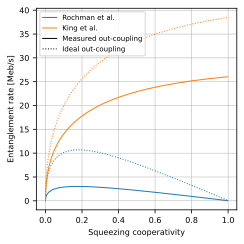

In [4]:
# Figure setup.
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1 * FIG_SIZES['onecol'],
        1 * FIG_SIZES['onecol']
        ),
    )

# Plot each experimental scenario (measured and ideal out-coupling).
for j, (label, params) in enumerate(scenarios.items()):
    for jj in range(2):
        axs.plot(
            C_list,
            ebit_rate[:, 2*j+jj, 0] * 2*np.pi * 1e3,
            color = (
                'tab:blue' if params == ROCHMAN_PARAMS else 
                'tab:orange' if params == KING_PARAMS else 
                'tab:green' if params == SAHU_PARAMS else 
                'k'
            ),
            linestyle = '-' if jj==0 else ':',
            label = label if jj==0 else None,
            )

# Fake plots to add to legend.
axs.plot([], [], color='black', linestyle='-', label='Measured out-coupling')
axs.plot([], [], color='black', linestyle=':', label='Ideal out-coupling')

# Legend, grid, and axis labels.
axs.legend(loc='upper left')
axs.grid('both')
axs.set_ylabel("Entanglement rate [Meb/s]")
axs.set_xlabel('Squeezing cooperativity')

# Save figure.
fig.tight_layout()
fig.savefig('fig/entanglement.pdf', bbox_inches='tight')